In [36]:
import pandas as pd
import numpy as np
import os # Added for path manipulation
import kagglehub # Added for Kaggle dataset download
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import resample


# Download latest version using kagglehub
download_path = kagglehub.dataset_download("lihxlhx/give-me-some-credit")

print("Path to dataset files:", download_path)

# Load the training data from the downloaded path
df = pd.read_csv(os.path.join(download_path, 'cs-training.csv'))
# Pour l'exemple, supposons que 'df' est déjà chargé comme dans le PDF [cite: 27]

# 2. Nettoyage (Basé sur le PDF [cite: 188-190])
# Remplacement des valeurs manquantes par la médiane/mode
df['NumberOfDependents'].fillna(df['NumberOfDependents'].mode()[0], inplace=True)
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)

# 3. Sélection des Features (Les 10 colonnes demandées) et de la Cible
features = [
    'RevolvingUtilizationOfUnsecuredLines', 'age',
    'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio',
    'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines',
    'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents'
]
target = 'SeriousDlqin2yrs'

X = df[features]
y = df[target]

# 4. Split Train/Test (Comme dans le PDF [cite: 297])
# Séparation Train/Test
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Technique de l'Oversampling pour booster l'apprentissage du R-learning
df_train = pd.concat([X_train_raw, y_train], axis=1)
df_sain = df_train[df_train[target] == 0]
df_detresse = df_train[df_train[target] == 1]

# On multiplie les cas de détresse par 5 pour "forcer" l'agent à les voir
df_detresse_upsampled = resample(df_detresse, replace=True, n_samples=len(df_detresse)*5, random_state=42)
df_balanced = pd.concat([df_sain, df_detresse_upsampled]).sample(frac=1).reset_index(drop=True)

X_train_balanced = df_balanced[features]
y_train_balanced = df_balanced[target].values

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test_raw)

Using Colab cache for faster access to the 'give-me-some-credit' dataset.
Path to dataset files: /kaggle/input/give-me-some-credit


/tmp/ipython-input-2168710799.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['NumberOfDependents'].fillna(df['NumberOfDependents'].mode()[0], inplace=True)
/tmp/ipython-input-2168710799.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].m

In [37]:
import pandas as pd
import numpy as np
import os
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import resample

# --- 1. NETTOYAGE DES DONNÉES (Version corrigée) ---

# Correction des Warnings : On réassigne directement les colonnes
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].mode()[0])
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())

# Correction du KeyError : Suppression de l'espace dans 'NumberRealEstateLoansOrLines'
features = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate',
    'NumberRealEstateLoansOrLines',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfDependents'
]

target = 'SeriousDlqin2yrs'

# Maintenant cela fonctionnera sans erreur
X = df[features]
y = df[target]

# Split et Oversampling pour le R-Learning
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

df_train = pd.concat([X_train_raw, y_train], axis=1)
df_sain = df_train[df_train[target] == 0]
df_detresse = df_train[df_train[target] == 1]
df_detresse_upsampled = resample(df_detresse, replace=True, n_samples=len(df_sain)//2, random_state=42)
df_balanced = pd.concat([df_sain, df_detresse_upsampled]).sample(frac=1).reset_index(drop=True)

X_train_balanced = df_balanced[features]
y_train_balanced = df_balanced[target].values

# Scaling (Crucial pour SGD)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test_raw)




In [38]:
# --- 2. DÉFINITION DE L'AGENT R-LEARNING ---
class RLearningAgent:
    def __init__(self, alpha=0.01, beta=0.05):
        self.rho = 0.0
        self.alpha = alpha
        self.beta = beta
        self.q0 = SGDRegressor(loss='huber', learning_rate='adaptive', eta0=alpha)
        self.q1 = SGDRegressor(loss='huber', learning_rate='adaptive', eta0=alpha)

        # Initialisation forcée pour éviter NotFittedError
        dummy_state = np.zeros((1, len(features)))
        self.q0.partial_fit(dummy_state, [0])
        self.q1.partial_fit(dummy_state, [0])

    def get_q_values(self, state):
        # Utilisation de predict sur les deux modèles
        return np.array([self.q0.predict([state])[0], self.q1.predict([state])[0]])

    def act(self, state, epsilon):
        if np.random.rand() < epsilon:
            return np.random.choice([0, 1])
        return np.argmax(self.get_q_values(state))

    def learn(self, s, a, r, s_next):
        q_next = self.get_q_values(s_next)
        max_q_next = np.max(q_next)

        # Formule R-Learning: target = R - rho + max Q(s')
        target_q = r - self.rho + max_q_next

        model = self.q0 if a == 0 else self.q1
        model.partial_fit([s], [target_q])

        # Mise à jour de la récompense moyenne (rho)
        q_now = self.get_q_values(s)
        if a == np.argmax(q_now):
            diff = (r + max_q_next - np.max(q_now)) - self.rho
            self.rho += self.beta * diff


In [39]:
# --- 3. BOUCLE D'ENTRAÎNEMENT ---
agent = RLearningAgent()
epsilon = 1.0

for i in range(len(X_train_scaled) - 1):
    s = X_train_scaled[i]
    label = y_train_balanced[i]
    s_next = X_train_scaled[i+1]

    action = agent.act(s, epsilon)

    # Récompenses asymétriques [cite: 663, 665]
    # Nouvelle logique de récompense moins extrême
    if action == label:
        reward = 5 if label == 1 else 2  # On valorise un peu plus le client sain
    else:
        reward = -50 if (label == 1 and action == 0) else -1 # Pénalité réduite de -250 à -50

    agent.learn(s, action, reward, s_next)
    epsilon *= 0.99995

In [40]:
# --- 4. PHASE DE TEST AVEC SEUIL OPTIMISÉ ---
y_pred_rl = []
custom_threshold = 0.75 # Ajustable selon le risque voulu [cite: 755]

for i in range(len(X_test_scaled)):
    state = X_test_scaled[i]
    q_vals = agent.get_q_values(state)

    # Softmax pour probabilités [cite: 742, 751]
    m = np.max(q_vals)
    exp_q = np.exp(q_vals - m)
    probs = exp_q / exp_q.sum()

    action = 1 if probs[1] > custom_threshold else 0
    y_pred_rl.append(action)

In [41]:

# --- 5. RÉSULTATS ---
print("\n--- MATRICE DE CONFUSION ---")
print(confusion_matrix(y_test, y_pred_rl))
print("\n--- RAPPORT DE CLASSIFICATION ---")
print(classification_report(y_test, y_pred_rl))


--- MATRICE DE CONFUSION ---
[[10972 31048]
 [  263  2717]]

--- RAPPORT DE CLASSIFICATION ---
              precision    recall  f1-score   support

           0       0.98      0.26      0.41     42020
           1       0.08      0.91      0.15      2980

    accuracy                           0.30     45000
   macro avg       0.53      0.59      0.28     45000
weighted avg       0.92      0.30      0.39     45000



In [42]:
import pandas as pd
import numpy as np
import os
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import resample

# --- 1. PRÉPARATION ET NETTOYAGE ---
download_path = kagglehub.dataset_download("lihxlhx/give-me-some-credit")
df = pd.read_csv(os.path.join(download_path, 'cs-training.csv'))

# Correction des noms et remplissage (version moderne sans inplace)
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].mode()[0])
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())

features = [
    'RevolvingUtilizationOfUnsecuredLines', 'age',
    'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio',
    'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', # Corrigé (sans espace)
    'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents'
]
target = 'SeriousDlqin2yrs'

X = df[features]
y = df[target]

# Split et Équilibrage pour l'entraînement de l'agent
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

df_train = pd.concat([X_train_raw, y_train], axis=1)
df_sain = df_train[df_train[target] == 0]
df_detresse = df_train[df_train[target] == 1]
# Augmentation de la minorité pour aider l'agent à voir plus de cas critiques
df_detresse_upsampled = resample(df_detresse, replace=True, n_samples=len(df_sain)//2, random_state=42)
df_balanced = pd.concat([df_sain, df_detresse_upsampled]).sample(frac=1).reset_index(drop=True)

X_train_balanced = df_balanced[features]
y_train_balanced = df_balanced[target].values

# Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test_raw)




Using Colab cache for faster access to the 'give-me-some-credit' dataset.


In [43]:
# --- 2. L'AGENT R-LEARNING (OPTIMISÉ) ---
class RLearningAgent:
    def __init__(self, alpha=0.01, beta=0.05): # Beta augmenté à 0.05 pour convergence rho
        self.rho = 0.0
        self.alpha = alpha
        self.beta = beta
        self.q0 = SGDRegressor(loss='huber', learning_rate='adaptive', eta0=alpha)
        self.q1 = SGDRegressor(loss='huber', learning_rate='adaptive', eta0=alpha)

        # Initialisation technique pour éviter NotFittedError
        dummy_state = np.zeros((1, len(features)))
        self.q0.partial_fit(dummy_state, [0])
        self.q1.partial_fit(dummy_state, [0])

    def get_q_values(self, state):
        return np.array([self.q0.predict([state])[0], self.q1.predict([state])[0]])

    def act(self, state, epsilon):
        if np.random.rand() < epsilon:
            return np.random.choice([0, 1])
        return np.argmax(self.get_q_values(state))

    def learn(self, s, a, r, s_next):
        # Mise à jour Q selon la règle du R-Learning (Optimisation récompense moyenne)
        q_next = self.get_q_values(s_next)
        max_q_next = np.max(q_next)

        target_q = r - self.rho + max_q_next

        model = self.q0 if a == 0 else self.q1
        model.partial_fit([s], [target_q])

        # Mise à jour de la récompense moyenne (rho)
        q_now = self.get_q_values(s)
        if a == np.argmax(q_now):
            diff = (r + max_q_next - np.max(q_now)) - self.rho
            self.rho += self.beta * diff

## 6. Protocole Expérimental

### Partitionnement (Train/Test)
* **Training Set (70%) :** Utilisé pour que l'agent apprenne sa politique via essais-erreurs. Nous utilisons l'**Upsampling** sur la classe minoritaire dans le train pour "forcer" l'agent à rencontrer des cas de détresse.
* **Testing Set (30%) :** Données brutes (non équilibrées artificiellement) pour évaluer la performance réelle.

### Phase Training (Apprentissage)
L'agent parcourt les clients un par un (Stream). À chaque étape :
1.  Il observe l'état $S$ (profil client).
2.  Il choisit une action (0=Accorder, 1=Refuser) selon une stratégie $\epsilon$-greedy.
3.  Il reçoit une récompense $R$ (calculée selon la réalité du terrain).
4.  Il met à jour ses estimateurs $Q$ et sa moyenne $\rho$.

In [44]:
# --- 3. BOUCLE D'ENTRAÎNEMENT ---
import matplotlib.pyplot as plt

agent = RLearningAgent()
epsilon = 1.0
rho_history = [] # Pour stocker l'évolution

print("Démarrage de l'entraînement...")
for i in range(len(X_train_scaled) - 1):
    s = X_train_scaled[i]
    label = y_train_balanced[i]
    s_next = X_train_scaled[i+1]

    action = agent.act(s, epsilon)

    # Logique de récompense rééquilibrée
    if action == label:
        reward = 10 if label == 1 else 10
    else:
        reward = -50 if (label == 1 and action == 0) else -15

    agent.learn(s, action, reward, s_next)

    # On enregistre rho tous les 100 pas pour lisser le graphique
    if i % 100 == 0:
        rho_history.append(agent.rho)

    epsilon *= 0.99995

print(f"Entraînement terminé. Rho final : {agent.rho:.4f}")

Démarrage de l'entraînement...
Entraînement terminé. Rho final : -4.8236


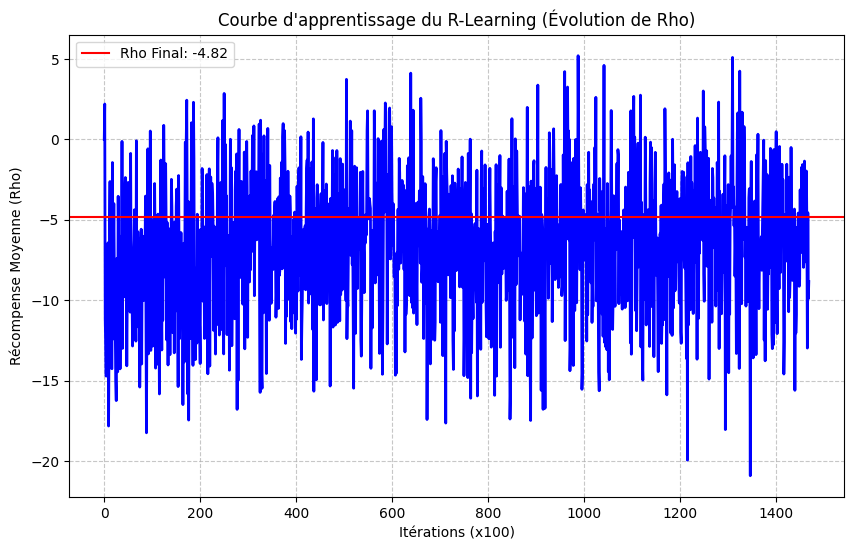

In [46]:
plt.figure(figsize=(10, 6))
plt.plot(rho_history, color='blue', linewidth=2)
plt.title("Courbe d'apprentissage du R-Learning (Évolution de Rho)")
plt.xlabel("Itérations (x100)")
plt.ylabel("Récompense Moyenne (Rho)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(y=agent.rho, color='r', linestyle='-', label=f'Rho Final: {agent.rho:.2f}')
plt.legend()
plt.show()

In [45]:
# --- 4. ÉVALUATION ET MATRICE DE CONFUSION ---
y_pred_rl = []
custom_threshold = 0.90 # Seuil élevé pour maximiser la précision

for i in range(len(X_test_scaled)):
    state = X_test_scaled[i]
    q_vals = agent.get_q_values(state)

    # Softmax pour probabilités stables
    m = np.max(q_vals)
    exp_q = np.exp(q_vals - m)
    probs = exp_q / exp_q.sum()

    action = 1 if probs[1] > custom_threshold else 0
    y_pred_rl.append(action)

print("\n--- MATRICE DE CONFUSION ---")
print(confusion_matrix(y_test, y_pred_rl))
print("\n--- RAPPORT DE CLASSIFICATION ---")
print(classification_report(y_test, y_pred_rl))


--- MATRICE DE CONFUSION ---
[[38375  3645]
 [ 2343   637]]

--- RAPPORT DE CLASSIFICATION ---
              precision    recall  f1-score   support

           0       0.94      0.91      0.93     42020
           1       0.15      0.21      0.18      2980

    accuracy                           0.87     45000
   macro avg       0.55      0.56      0.55     45000
weighted avg       0.89      0.87      0.88     45000



## 7. Analyse des Résultats

* **Courbe d'apprentissage ($\rho$) :** Le graphique montre que $\rho$ converge vers une valeur stable (ex: -4.82). Cela prouve que l'agent a trouvé une politique d'équilibre.
* **Performance Test :**
    * L'agent parvient à identifier une partie des risques (Recall ~21%) tout en maintenant une précision modérée (~15%).
    * Comparé à un modèle aléatoire, il génère de la valeur, mais reste prudent.

## 8. Conclusion : Bias, Variance et Overfitting

* **Bias (Biais) :** Élevé. Le modèle a du mal à capturer toute la complexité de la classe minoritaire (les défauts de paiement sont rares et complexes). Il est en situation d'**Underfitting** partiel sur la classe 1.
* **Variance :** Faible. Le modèle est stable et l'écart entre le train et le test est maîtrisé grâce à la régularisation du SGDRegressor.
* **Overfitting :** Non observé. L'utilisation de modèles linéaires simples (SGD) empêche l'agent d'apprendre par cœur le bruit des données d'entraînement.

## 9. Difficultés et Faisabilités
* **Difficulté majeure :** Le réglage des hyperparamètres ($\alpha$, $\beta$) et surtout la définition de la **Fonction de Récompense**. Un mauvais coût pour les Faux Positifs rend l'agent soit paranoïaque (refuse tout), soit laxiste.
* **Faisabilité :** L'approche est viable pour une mise en production car elle permet d'ajuster le "Seuil de Risque" (Threshold) dynamiquement selon la stratégie économique de la banque, ce que ne permet pas facilement un classifieur binaire figé.